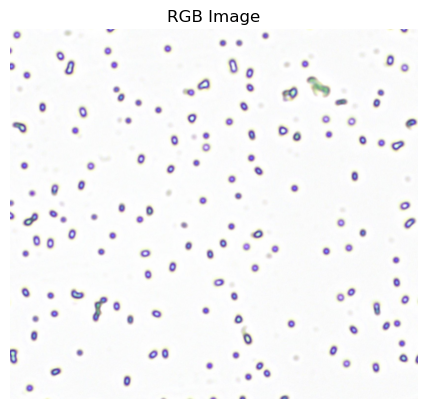

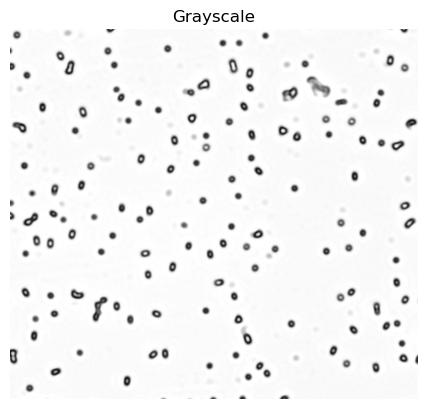

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('mic.jpg', ) 
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.subplot(1, 1, 1)
plt.imshow(image, cmap='gray')
plt.title("RGB Image")
plt.axis("off")
plt.show()

plt.subplot(1, 1, 1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")
plt.show()

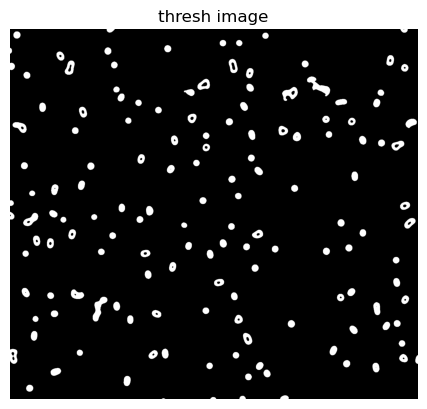

In [2]:
# Perfrom OTSU thresholding, which separates foreground from background
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

plt.subplot(1, 1, 1)
plt.imshow(thresh, cmap='gray')
plt.title("thresh image")
plt.axis("off")
plt.show()

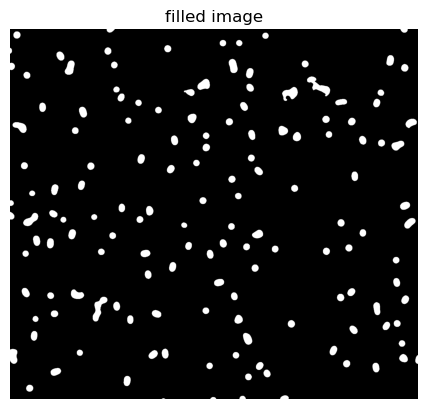

In [3]:
flood_filled = thresh.copy()
h, w = thresh.shape[:2]
mask = np.zeros((h+2, w+2), np.uint8)

# Flood fill from point (0, 0)
cv2.floodFill(flood_filled, mask, (0, 0), 255)

# Invert flood-filled image
flood_filled_inv = cv2.bitwise_not(flood_filled)

# Combine with original to fill holes
filled = thresh | flood_filled_inv

plt.subplot(1, 1, 1)
plt.imshow(filled, cmap='gray')
plt.title("filled image")
plt.axis("off")
plt.show()

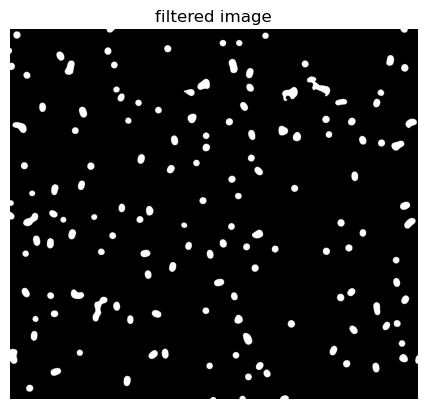

In [4]:
# Find connected components
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(filled, connectivity=8)

# Create an output image to hold filtered components
filtered_img = np.zeros_like(filled)

# Minimum area threshold (tweak as needed)
min_area = 100

# Keep components above the area threshold
for i in range(1, num_labels):  # skip background (label 0)
    if stats[i, cv2.CC_STAT_AREA] >= min_area:
        filtered_img[labels == i] = 255

plt.subplot(1, 1, 1)
plt.imshow(filtered_img, cmap='gray')
plt.title("filtered image")
plt.axis("off")
plt.show()

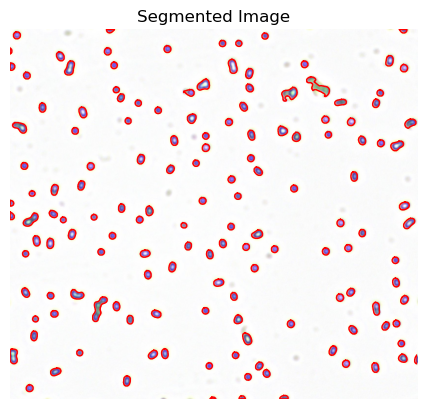

In [5]:
contours, _= cv2.findContours(filtered_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE) 
contours = [i for i in contours if i.shape[0]>3] # to include counters with more than 3 edges
contours = [i[:,0,:] for i in contours]
contours = [np.vstack([i, i[0,:]]) for i in contours]     

plt.subplot(1, 1, 1)
plt.imshow(image)
if len(contours)>0:
    for c in contours:
        plt.plot(c[:,0],c[:,1], c = 'r', linewidth = 1)
plt.axis('off')
plt.title('Segmented Image')
plt.show()